In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [ ]:
PROJECT_DIR   = Path.cwd().resolve().parent
EXTRACT_DIR   = PROJECT_DIR / 'processed' / 'extraction'
TRANSFORM_DIR = PROJECT_DIR / 'processed' / 'transform'
OUTPUT_DIR    = PROJECT_DIR / 'outputs' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# Updated transform outputs
binned_timeseries = pd.read_csv(TRANSFORM_DIR / 'events_12h_binned.csv')
cohort_final      = pd.read_csv(TRANSFORM_DIR / 'cohort_final.csv')

for df, cols in [
    (binned_timeseries, ['bin_start', 'bin_end', 'intime', 'outtime']),
    (cohort_final, ['intime', 'outtime', 'admittime', 'dischtime', 'deathtime']),
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"12h binned table: {binned_timeseries.shape}")
print(f"Cohort stays: {cohort_final['stay_id'].nunique():,}")


12h binned table: (7653, 171)
Cohort stays: 775


## EDA: 환자 기본정보

In [ ]:
def first_mode(values):
    mode_values = values.dropna().mode()
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]

subject_anthropometrics = (
    binned_timeseries
    .groupby("subject_id")
    .agg(
        height=("height", "median"),
        weight=("weight", "median"),
    )
    .reset_index()
)

# subject-level 요약 테이블
subject_summary = (
    cohort_final
    .sort_values(['subject_id', 'intime'])
    .groupby('subject_id')
    .agg(
        ever_delirium=('ever_delirium', 'max'),
        n_stays=('stay_id', 'nunique'),
        first_age=('anchor_age', 'first'),
        gender=('gender', 'first'),
        race=('race', first_mode),
        admission_type=('admission_type', first_mode),
        specialty=('specialty', first_mode),
        first_intime=('intime', 'min'),
        last_outtime=('outtime', 'max'),
        total_icu_los_hours=('icu_los_hours', 'sum'),
    )
    .reset_index()
    .merge(subject_anthropometrics, on="subject_id", how="left")
)

stay_summary = cohort_final[['subject_id', 'stay_id', 'anchor_age', 'gender', 'race', 'admission_type', 'icu_los_hours', 'ever_delirium']].copy()

print('=== Cohort overview ===')
print(f"Subjects: {subject_summary['subject_id'].nunique():,}")
print(f"Stays: {cohort_final['stay_id'].nunique():,}")

print()
print('=== ever_delirium 분포 (subject-level) ===')
print(subject_summary['ever_delirium'].value_counts().sort_index())
print((subject_summary['ever_delirium'].value_counts(normalize=True).sort_index() * 100).round(2))

=== Cohort overview ===
Subjects: 489
Stays: 775

=== ever_delirium 분포 (subject-level) ===
ever_delirium
0    211
1    278
Name: count, dtype: int64
ever_delirium
0    43.15
1    56.85
Name: proportion, dtype: float64


In [ ]:
# 12시간 bin-level outcome label 분포
def summarize_delirium_labels(df, mask, label):
    labeled = df.loc[mask & df["delirium"].notna(), "delirium"]
    n_labels = len(labeled)
    n_delirium = int(labeled.eq(1).sum())
    n_non_delirium = int(labeled.eq(0).sum())
    return {
        "label_scope": label,
        "n_labels": n_labels,
        "n_delirium": n_delirium,
        "n_non_delirium": n_non_delirium,
        "delirium_pct": n_delirium / n_labels * 100 if n_labels else np.nan,
    }

delirium_label_summary = pd.DataFrame([
    summarize_delirium_labels(binned_timeseries, pd.Series(True, index=binned_timeseries.index), "All 12h labels"),
    summarize_delirium_labels(binned_timeseries, binned_timeseries["hours"].ge(48), "Labels from 48h onward"),
    summarize_delirium_labels(binned_timeseries, binned_timeseries["hours"].le(36), "Labels through 36h"),
])
delirium_label_summary["delirium_pct"] = delirium_label_summary["delirium_pct"].round(2)

print()
print("=== delirium label 분포 (12h bin-level) ===")
delirium_label_summary.to_csv(OUTPUT_DIR / 'delirium_label_summary.csv', index=False)
display(delirium_label_summary)



=== delirium label 분포 (12h bin-level) ===


,label_scope,n_labels,n_delirium,n_non_delirium,delirium_pct
0,All 12h labels,7653,1535,6118,20.06
1,Labels from 48h onward,5328,1075,4253,20.18
2,Labels through 36h,2325,460,1865,19.78


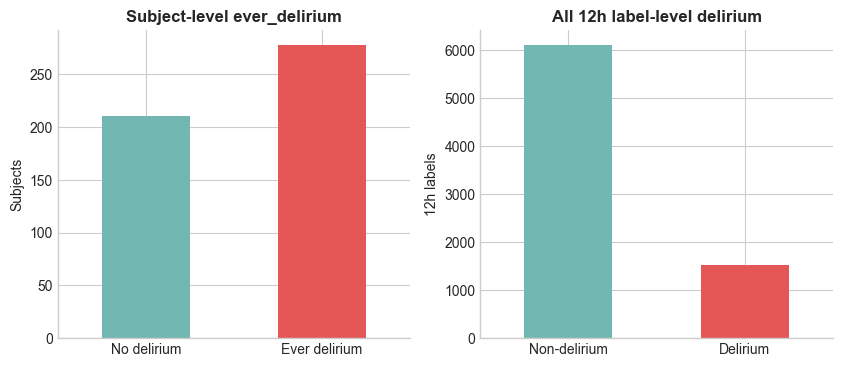

In [ ]:
# Delirium 분포
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# patient-level (ever_delirium)
subject_summary["ever_delirium"].value_counts().sort_index().rename({0: "No delirium", 1: "Ever delirium"}).plot(
    kind="bar", ax=axes[0], color=["#72B7B2", "#E45756"]
)
axes[0].set_title("Subject-level ever_delirium")
axes[0].set_xlabel("")
axes[0].set_ylabel("Subjects")
axes[0].tick_params(axis="x", rotation=0)

# 12h label-level (delirium labels)
all_label_row = delirium_label_summary.loc[delirium_label_summary["label_scope"].eq("All 12h labels")].iloc[0]
pd.Series(
    {
        "Non-delirium": all_label_row["n_non_delirium"],
        "Delirium": all_label_row["n_delirium"],
    }
).plot(kind="bar", ax=axes[1], color=["#72B7B2", "#E45756"])
axes[1].set_title("All 12h label-level delirium")
axes[1].set_xlabel("")
axes[1].set_ylabel("12h labels")
axes[1].tick_params(axis="x", rotation=0)

fig.savefig(OUTPUT_DIR / 'delirium_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


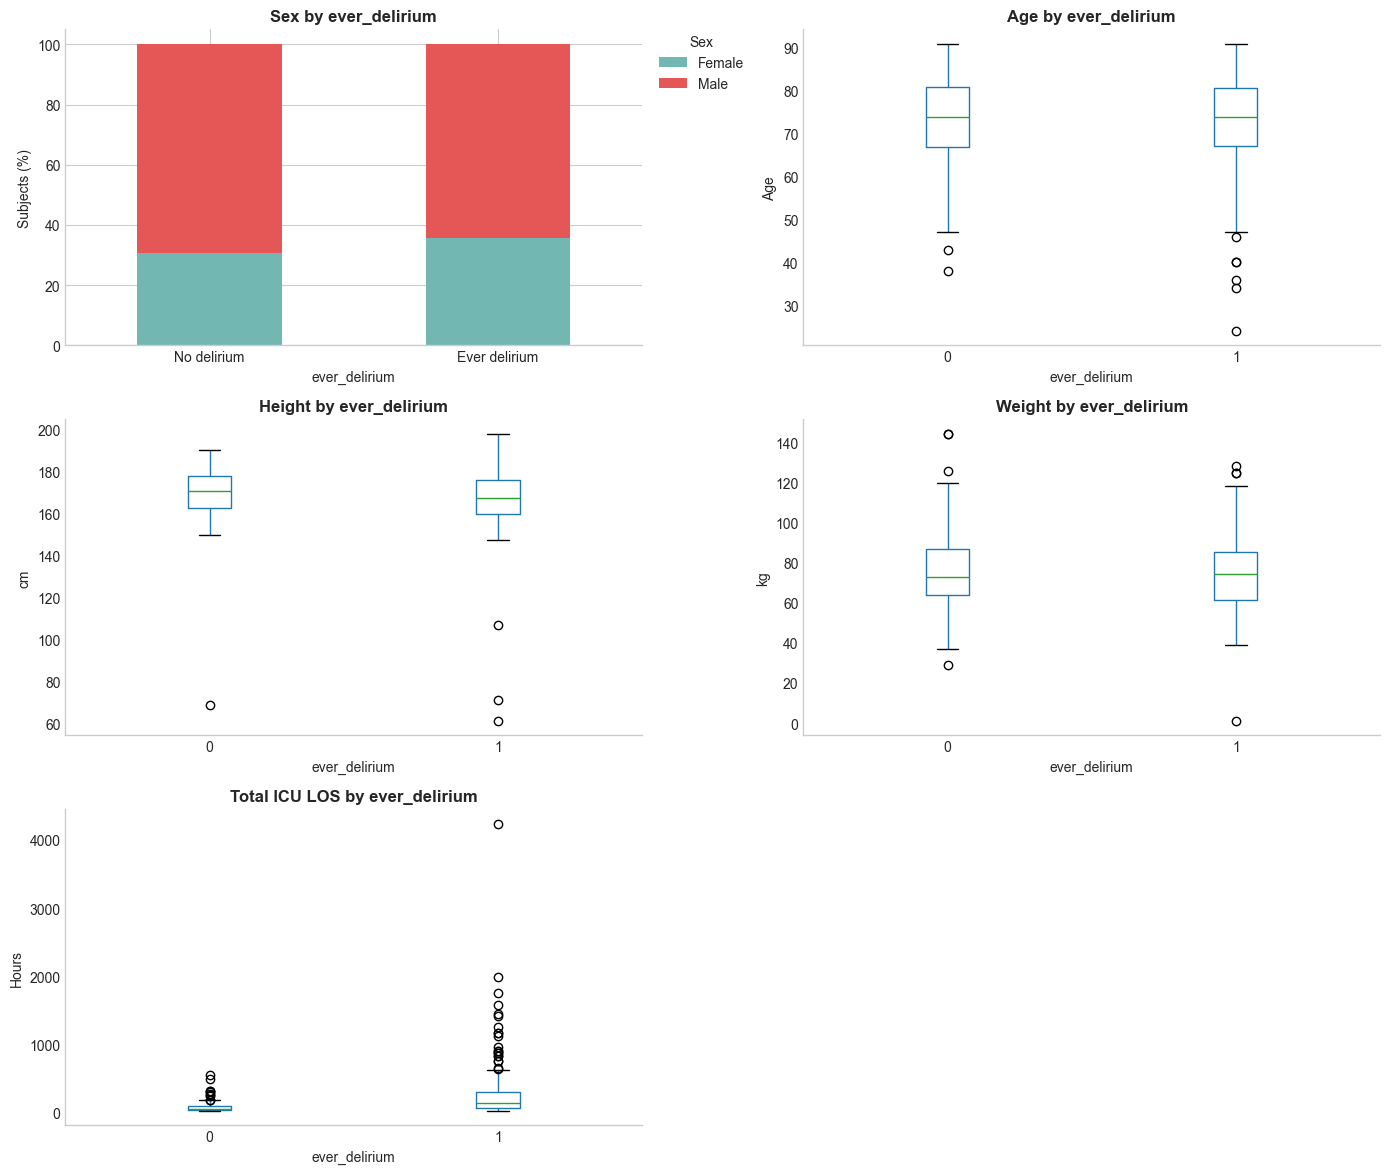

In [ ]:
plot_summary = subject_summary.copy()
plot_summary["sex"] = plot_summary["gender"].map({"M": "Male", "F": "Female"}).fillna(plot_summary["gender"])

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

sex_by_delirium = pd.crosstab(plot_summary["ever_delirium"], plot_summary["sex"])
sex_by_delirium = sex_by_delirium.rename(index={0: "No delirium", 1: "Ever delirium"})
sex_by_delirium_pct = sex_by_delirium.div(sex_by_delirium.sum(axis=1), axis=0) * 100
sex_by_delirium_pct.plot(kind="bar", stacked=True, ax=axes[0, 0], color=["#72B7B2", "#E45756"])
axes[0, 0].set_title("Sex by ever_delirium")
axes[0, 0].set_xlabel("ever_delirium")
axes[0, 0].set_ylabel("Subjects (%)")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend(title="Sex", frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

subject_summary.boxplot(column="first_age", by="ever_delirium", ax=axes[0, 1], grid=False)
axes[0, 1].set_title("Age by ever_delirium")
axes[0, 1].set_xlabel("ever_delirium")
axes[0, 1].set_ylabel("Age")

subject_summary.boxplot(column="height", by="ever_delirium", ax=axes[1, 0], grid=False)
axes[1, 0].set_title("Height by ever_delirium")
axes[1, 0].set_xlabel("ever_delirium")
axes[1, 0].set_ylabel("cm")

subject_summary.boxplot(column="weight", by="ever_delirium", ax=axes[1, 1], grid=False)
axes[1, 1].set_title("Weight by ever_delirium")
axes[1, 1].set_xlabel("ever_delirium")
axes[1, 1].set_ylabel("kg")

subject_summary.boxplot(column="total_icu_los_hours", by="ever_delirium", ax=axes[2, 0], grid=False)
axes[2, 0].set_title("Total ICU LOS by ever_delirium")
axes[2, 0].set_xlabel("ever_delirium")
axes[2, 0].set_ylabel("Hours")

axes[2, 1].axis("off")

fig.suptitle("")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'baseline_characteristics_plots.png', dpi=300, bbox_inches='tight')
plt.show()


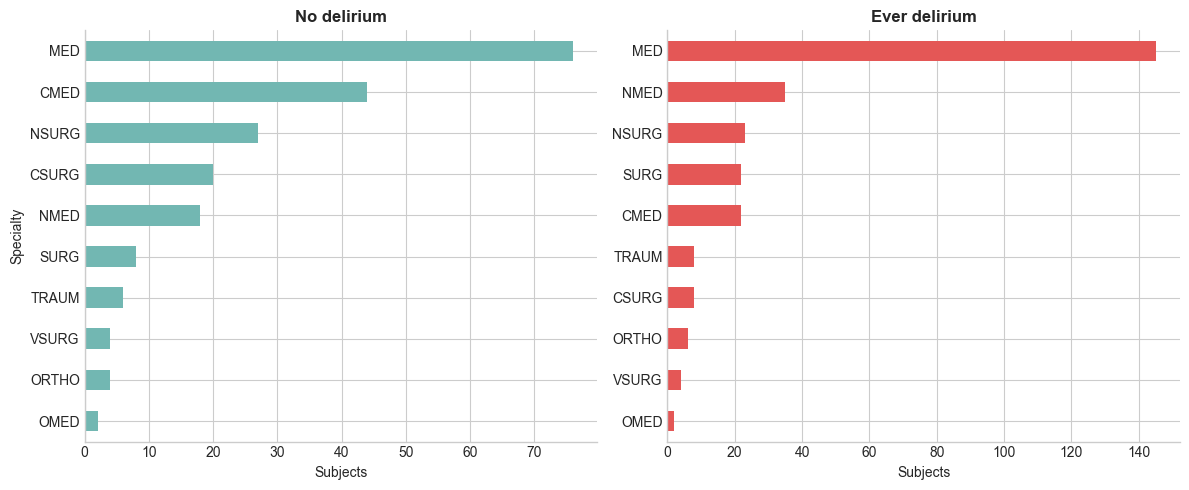

In [ ]:
# Specialty 분포
top_specialties = plot_summary["specialty"].dropna().value_counts().head(10).index
specialty_plot = plot_summary[plot_summary["specialty"].isin(top_specialties)].copy()
specialty_counts = pd.crosstab(specialty_plot["specialty"], specialty_plot["ever_delirium"])
specialty_counts = specialty_counts.rename(columns={0: "No delirium", 1: "Ever delirium"})
specialty_counts = specialty_counts.reindex(columns=["No delirium", "Ever delirium"], fill_value=0)
no_delirium_specialty = specialty_counts["No delirium"].sort_values()
ever_delirium_specialty = specialty_counts["Ever delirium"].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
no_delirium_specialty.plot(kind="barh", ax=axes[0], color="#72B7B2")
axes[0].set_title("No delirium")
axes[0].set_xlabel("Subjects")
axes[0].set_ylabel("Specialty")
ever_delirium_specialty.plot(kind="barh", ax=axes[1], color="#E45756")
axes[1].set_title("Ever delirium")
axes[1].set_xlabel("Subjects")
axes[1].set_ylabel("")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'specialty_distribution_by_delirium.png', dpi=300, bbox_inches='tight')
plt.show()

,Variable,Group,n,Shapiro-Wilk W,Shapiro-Wilk p
0,Age (years),Delirium,278,0.9448,0.0000
1,Age (years),Non-delirium,211,0.9710,0.0002
2,Height (cm),Delirium,175,0.7629,0.0000
3,Height (cm),Non-delirium,104,0.7382,0.0000
4,Weight (kg),Delirium,278,0.9873,0.0152
5,Weight (kg),Non-delirium,211,0.9647,0.0000
6,ICU length of stay (days),Delirium,278,0.5199,0.0000
7,ICU length of stay (days),Non-delirium,211,0.6611,0.0000


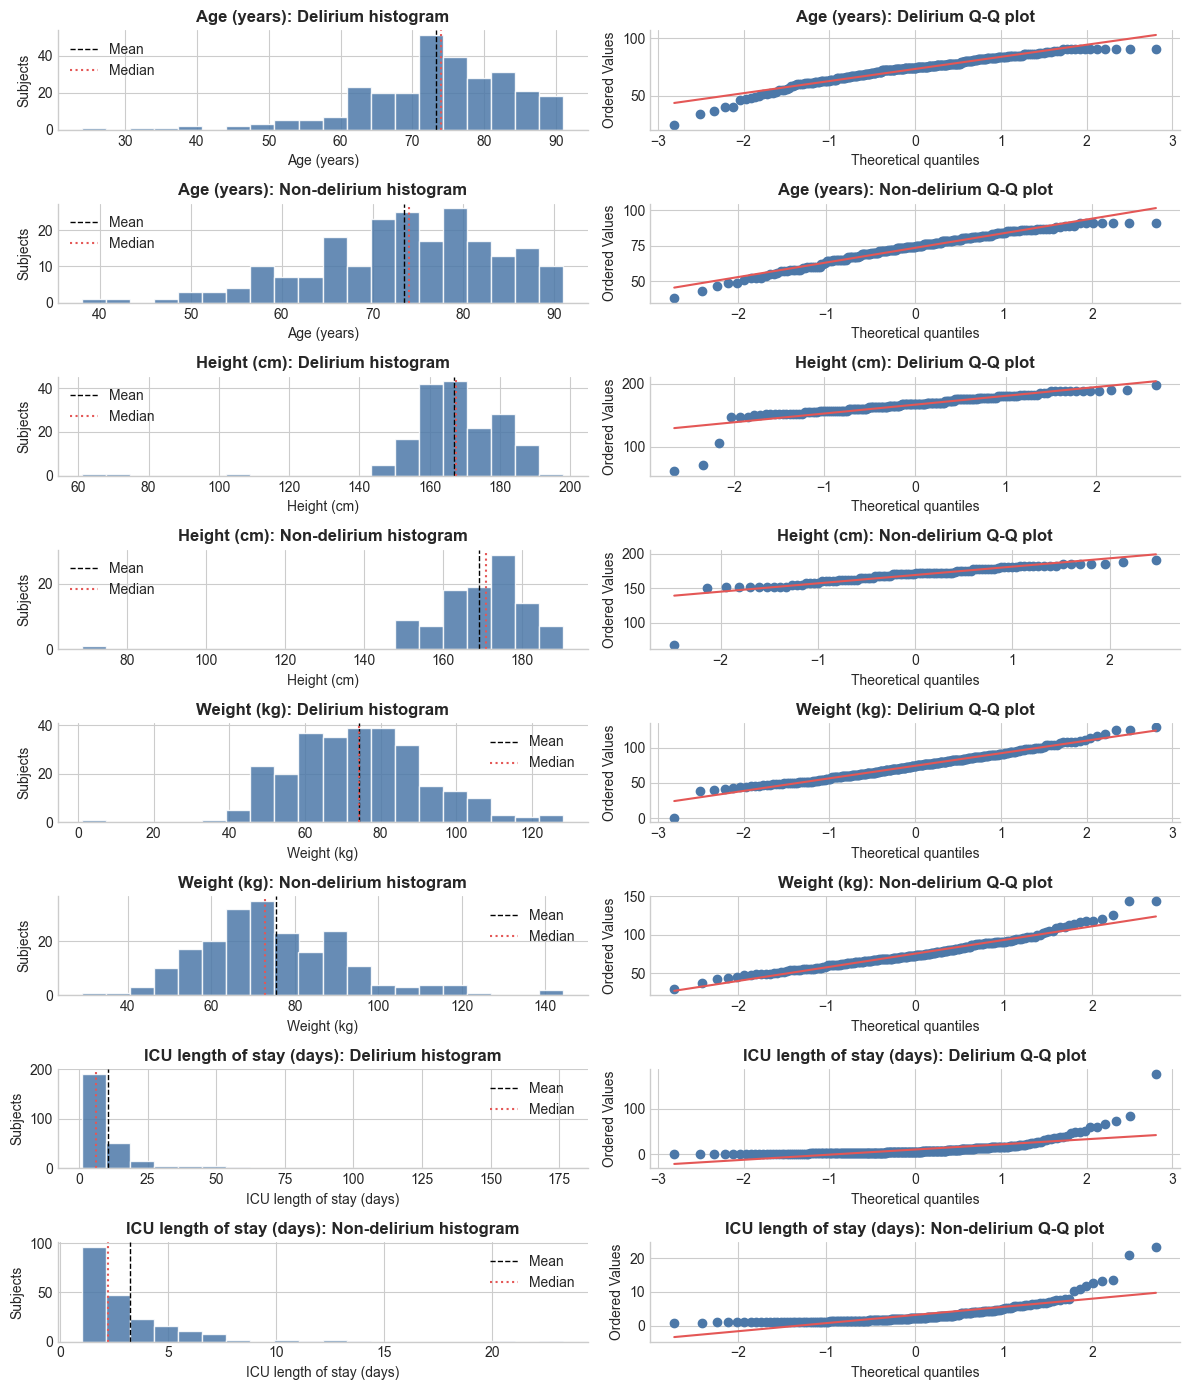

In [ ]:
# 정규성 진단: Shapiro-Wilk test, histogram, Q-Q plot.
normality_df = subject_summary.copy()
normality_df["total_icu_los_days"] = normality_df["total_icu_los_hours"] / 24
normality_variables = [
    ("Age (years)", "first_age"),
    ("Height (cm)", "height"),
    ("Weight (kg)", "weight"),
    ("ICU length of stay (days)", "total_icu_los_days"),
]
normality_groups = [(1, "Delirium"), (0, "Non-delirium")]

normality_rows = []
for variable_label, column in normality_variables:
    for group_value, group_label in normality_groups:
        values = normality_df.loc[normality_df["ever_delirium"].eq(group_value), column].dropna()
        if len(values) >= 3:
            shapiro_stat, shapiro_p = stats.shapiro(values)
        else:
            shapiro_stat, shapiro_p = np.nan, np.nan
        normality_rows.append({
            "Variable": variable_label,
            "Group": group_label,
            "n": len(values),
            "Shapiro-Wilk W": shapiro_stat,
            "Shapiro-Wilk p": shapiro_p,
        })

normality_summary = pd.DataFrame(normality_rows)
normality_summary_display = normality_summary.copy()
for col in ["Shapiro-Wilk W", "Shapiro-Wilk p"]:
    normality_summary_display[col] = normality_summary_display[col].round(4)

display(normality_summary_display)
normality_summary_display.to_csv(OUTPUT_DIR / 'normality_summary.csv', index=False)

fig, axes = plt.subplots(len(normality_variables) * len(normality_groups), 2, figsize=(12, 14))
for row_idx, (variable_label, column) in enumerate(normality_variables):
    for group_idx, (group_value, group_label) in enumerate(normality_groups):
        plot_idx = row_idx * len(normality_groups) + group_idx
        values = normality_df.loc[normality_df["ever_delirium"].eq(group_value), column].dropna()

        axes[plot_idx, 0].hist(values, bins=20, color="#4C78A8", alpha=0.85, edgecolor="white")
        axes[plot_idx, 0].axvline(values.mean(), color="black", linestyle="--", linewidth=1, label="Mean")
        axes[plot_idx, 0].axvline(values.median(), color="#E45756", linestyle=":", linewidth=1.5, label="Median")
        axes[plot_idx, 0].set_title(f"{variable_label}: {group_label} histogram")
        axes[plot_idx, 0].set_xlabel(variable_label)
        axes[plot_idx, 0].set_ylabel("Subjects")
        axes[plot_idx, 0].legend(frameon=False)

        stats.probplot(values, dist="norm", plot=axes[plot_idx, 1])
        axes[plot_idx, 1].set_title(f"{variable_label}: {group_label} Q-Q plot")
        axes[plot_idx, 1].get_lines()[0].set_markerfacecolor("#4C78A8")
        axes[plot_idx, 1].get_lines()[0].set_markeredgecolor("#4C78A8")
        axes[plot_idx, 1].get_lines()[1].set_color("#E45756")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'normality_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Table 1 (characteristics)
characteristics_df = subject_summary.copy()
characteristics_df["total_icu_los_days"] = characteristics_df["total_icu_los_hours"] / 24

def collapse_race(value): # 종류 너무 다양함.
    if pd.isna(value):
        return np.nan
    value = str(value).upper()
    if "WHITE" in value:
        return "White"
    if "BLACK" in value:
        return "Black/African American"
    if "ASIAN" in value:
        return "Asian"
    if "HISPANIC" in value or "LATINO" in value:
        return "Hispanic/Latino"
    if "UNKNOWN" in value or "UNABLE" in value or "DECLINED" in value:
        return "Unknown"
    return "Other"


characteristics_df["race_group"] = characteristics_df["race"].map(collapse_race)
characteristics_df["sex"] = characteristics_df["gender"].map({"M": "Male", "F": "Female"}).fillna(characteristics_df["gender"])

delirium_col = f"Delirium (n = {characteristics_df['ever_delirium'].eq(1).sum():,})"
non_delirium_col = f"Non-delirium (n = {characteristics_df['ever_delirium'].eq(0).sum():,})"


def format_pvalue(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return "<.001"
    return f"{p_value:.3f}".lstrip("0")


def mean_sd(series):
    values = series.dropna()
    return f"{values.mean():.2f} ({values.std(ddof=1):.2f})" if len(values) else ""


def median_iqr(series):
    values = series.dropna()
    if not len(values):
        return ""
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    return f"{values.median():.0f} ({q1:.0f}-{q3:.0f})"


def n_pct(series, value):
    values = series.dropna()
    denom = len(values)
    count = int(values.eq(value).sum())
    return f"{count:,} ({count / denom * 100:.1f}%)" if denom else "0 (0.0%)"


def continuous_pvalue(column):
    delirium_values = characteristics_df.loc[characteristics_df["ever_delirium"].eq(1), column].dropna()
    non_delirium_values = characteristics_df.loc[characteristics_df["ever_delirium"].eq(0), column].dropna()
    if len(delirium_values) == 0 or len(non_delirium_values) == 0:
        return np.nan
    return stats.mannwhitneyu(delirium_values, non_delirium_values, alternative="two-sided").pvalue


def categorical_pvalue(column, categories=None):
    subset = characteristics_df[["ever_delirium", column]].dropna()
    if categories is not None:
        subset = subset[subset[column].isin(categories)]
    contingency = pd.crosstab(subset[column], subset["ever_delirium"])
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return np.nan
    return stats.chi2_contingency(contingency)[1]


rows = []


def add_parent(label, p_value):
    rows.append({"Characteristic": label, delirium_col: "", non_delirium_col: "", "P value": format_pvalue(p_value)})


def add_child(label, delirium_value, non_delirium_value):
    rows.append({"Characteristic": f"  {label}", delirium_col: delirium_value, non_delirium_col: non_delirium_value, "P value": ""})


def add_continuous_block(label, column):
    add_parent(label, continuous_pvalue(column))
    add_child(
        "Mean (SD)",
        mean_sd(characteristics_df.loc[characteristics_df["ever_delirium"].eq(1), column]),
        mean_sd(characteristics_df.loc[characteristics_df["ever_delirium"].eq(0), column]),
    )
    add_child(
        "Median (IQR)",
        median_iqr(characteristics_df.loc[characteristics_df["ever_delirium"].eq(1), column]),
        median_iqr(characteristics_df.loc[characteristics_df["ever_delirium"].eq(0), column]),
    )


def add_categorical_block(label, column, categories):
    categories = [category for category in categories if pd.notna(category)]
    add_parent(label, categorical_pvalue(column, categories))
    delirium_series = characteristics_df.loc[characteristics_df["ever_delirium"].eq(1), column]
    non_delirium_series = characteristics_df.loc[characteristics_df["ever_delirium"].eq(0), column]
    for category in categories:
        add_child(category, n_pct(delirium_series, category), n_pct(non_delirium_series, category))


race_categories = ["White", "Black/African American", "Asian", "Hispanic/Latino", "Other", "Unknown"]
admission_type_categories = characteristics_df["admission_type"].dropna().value_counts().index.tolist()
sex_categories = [category for category in ["Male", "Female"] if category in set(characteristics_df["sex"].dropna())]
specialty_top10 = characteristics_df["specialty"].dropna().value_counts().head(10).index.tolist()

add_continuous_block("Age (years)", "first_age")
add_categorical_block("Sex", "sex", sex_categories)
add_continuous_block("Height (cm)", "height")
add_continuous_block("Weight (kg)", "weight")
add_continuous_block("ICU length of stay (days)", "total_icu_los_days")
add_categorical_block("Race", "race_group", race_categories)
add_categorical_block("Admission type", "admission_type", admission_type_categories)
add_categorical_block("Specialty (top 10)", "specialty", specialty_top10)

characteristics_table = pd.DataFrame(rows)

characteristics_table.to_csv(OUTPUT_DIR / 'table1_characteristics.csv', index=False)
display(characteristics_table)


,Characteristic,Delirium (n = 278),Non-delirium (n = 211),P value
0,Age (years),,,.938
1,Mean (SD),73.25 (10.84),73.44 (10.33),
2,Median (IQR),74 (67-81),74 (67-81),
3,Sex,,,.309
4,Male,179 (64.4%),146 (69.2%),
5,Female,99 (35.6%),65 (30.8%),
6,Height (cm),,,.136
7,Mean (SD),167.04 (16.01),169.17 (13.99),
8,Median (IQR),168 (160-176),171 (163-178),
9,Weight (kg),,,.754
